# AML Mule Account Detection — Exploratory Data Analysis

## Hackathon Phase 2

### Objective
Identify bank accounts acting as **money mule accounts** used for laundering funds.

Mule accounts typically exhibit patterns such as:

- Rapid inflow and outflow of funds
- Large transaction bursts
- Many counterparties
- Round-number transfers
- Structuring transactions below reporting thresholds
- Geographic inconsistencies

This notebook explores the dataset to uncover behavioral patterns that may distinguish mule accounts from legitimate ones.

---

### Dataset Summary

| Dataset | Description |
|------|------|
| customers | KYC and customer attributes |
| accounts | Account-level attributes |
| transactions | 5 years of transaction data |
| demographics | Customer demographic information |
| product_details | Financial product holdings |
| branch | Branch-level metadata |
| train_labels | Mule account labels |

Total scale:

- ~160k accounts
- ~400M transactions
- 5 years of activity (2020–2025)

## 1. Import Libraries

We import libraries required for:

- Data processing
- Visualization
- Database querying (DuckDB)
- Machine learning prototypes

In [65]:
import pandas as pd
import numpy as np
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

sns.set_style("darkgrid")

pd.set_option("display.max_columns", None)

## 2. Load Core Datasets

We load all smaller datasets completely into memory.  
Transaction tables are extremely large (~400M rows) and will be accessed using **DuckDB queries** later.

In [66]:
DATA = "../data/"

customers = pd.read_parquet(DATA + "customers.parquet")
accounts = pd.read_parquet(DATA + "accounts.parquet")
accounts_add = pd.read_parquet(DATA + "accounts-additional.parquet")
demographics = pd.read_parquet(DATA + "demographics.parquet")
product_details = pd.read_parquet(DATA + "product_details.parquet")
branch = pd.read_parquet(DATA + "branch.parquet")
linkage = pd.read_parquet(DATA + "customer_account_linkage.parquet")
labels = pd.read_parquet(DATA + "train_labels.parquet")
test_accounts = pd.read_parquet(DATA + "test_accounts.parquet")

## 3. Dataset Overview

Understanding dataset size helps determine which tables require sampling or database querying.

In [67]:
datasets = {
    "customers": customers,
    "accounts": accounts,
    "accounts_add": accounts_add,
    "demographics": demographics,
    "product_details": product_details,
    "branch": branch,
    "linkage": linkage,
    "labels": labels,
    "test_accounts": test_accounts
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (159416, 14)
accounts: (160153, 22)
accounts_add: (160153, 2)
demographics: (159416, 9)
product_details: (159416, 11)
branch: (9000, 9)
linkage: (160153, 2)
labels: (96091, 5)
test_accounts: (64062, 1)


## 4. Data Schema Inspection

Before performing analysis, we inspect the schema to understand:

- categorical variables
- numerical attributes
- date columns

In [68]:
accounts.info()
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 160153 entries, 0 to 160152
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   account_id               160153 non-null  str    
 1   account_status           160153 non-null  str    
 2   product_code             160153 non-null  int64  
 3   currency_code            160153 non-null  int64  
 4   account_opening_date     160153 non-null  str    
 5   branch_code              160153 non-null  int64  
 6   branch_pin               144648 non-null  float64
 7   avg_balance              150685 non-null  float64
 8   product_family           160153 non-null  str    
 9   nomination_flag          160153 non-null  str    
 10  cheque_allowed           160153 non-null  str    
 11  cheque_availed           160153 non-null  str    
 12  num_chequebooks          160153 non-null  int64  
 13  last_mobile_update_date  24235 non-null   str    
 14  kyc_compliant  

## 5. Account–Customer Relationship

A customer may hold **multiple bank accounts**.  
To analyze account behavior we merge:

accounts → linkage → customers

In [69]:
df = accounts.merge(linkage, on="account_id")
df = df.merge(customers, on="customer_id")
df = df.merge(labels, on="account_id")
df.head()

,account_id,account_status,product_code,currency_code,account_opening_date,branch_code,branch_pin,avg_balance,product_family,nomination_flag,cheque_allowed,cheque_availed,num_chequebooks,last_mobile_update_date,kyc_compliant,last_kyc_date,rural_branch,monthly_avg_balance,quarterly_avg_balance,daily_avg_balance,freeze_date,unfreeze_date,customer_id,date_of_birth,relationship_start_date,pan_available,aadhaar_available,passport_available,mobile_banking_flag,internet_banking_flag,atm_card_flag,demat_flag,credit_card_flag,fastag_flag,customer_pin,permanent_pin,is_mule,mule_flag_date,alert_reason,flagged_by_branch
0,ACCT_000000,active,200,1,2023-08-30,7982,515008.0,53720.31,K,Y,Y,Y,0,NaN,Y,2023-11-04,Y,50111.60,55554.79,66771.57,NaN,NaN,CUST_000000,1950-07-15,2019-10-03,Y,Y,N,Y,Y,Y,N,Y,N,515008,515008,0,NaN,NaN,NaN
1,ACCT_000002,active,1133,1,2019-08-05,5479,144074.0,9492.82,O,N,N,N,0,NaN,Y,2021-10-03,N,9169.02,6925.45,8737.84,NaN,NaN,CUST_000002,1985-08-01,1999-08-19,N,N,N,Y,N,Y,N,N,N,144074,144074,0,NaN,NaN,NaN
2,ACCT_000003,active,146,1,2023-10-31,8227,190033.0,93286.70,S,N,Y,Y,3,NaN,Y,2024-10-25,N,86326.00,100171.75,78181.17,NaN,NaN,CUST_000003,1972-03-18,2018-04-28,N,Y,N,N,N,Y,N,N,N,190033,190033,0,NaN,NaN,NaN
3,ACCT_000004,active,191,1,2017-11-25,3285,400035.0,555715.54,K,Y,Y,N,0,NaN,Y,2023-10-29,N,647193.23,509836.62,699191.21,NaN,NaN,CUST_000004,1971-11-06,2006-04-05,N,NaN,Y,N,N,N,N,Y,N,400035,400035,0,NaN,NaN,NaN
4,ACCT_000008,frozen,897,1,2023-12-11,5486,249002.0,-28404.67,S,Y,Y,N,0,NaN,Y,2022-01-13,N,-26399.15,-20418.49,-24290.59,2022-03-15,NaN,CUST_000008,1957-06-29,2016-11-25,N,N,Y,Y,Y,Y,N,N,N,560029,342022,0,NaN,NaN,NaN


## 6. Mule Account Distribution

Fraud detection datasets are typically **highly imbalanced**.  
We analyze the distribution of mule vs legitimate accounts.

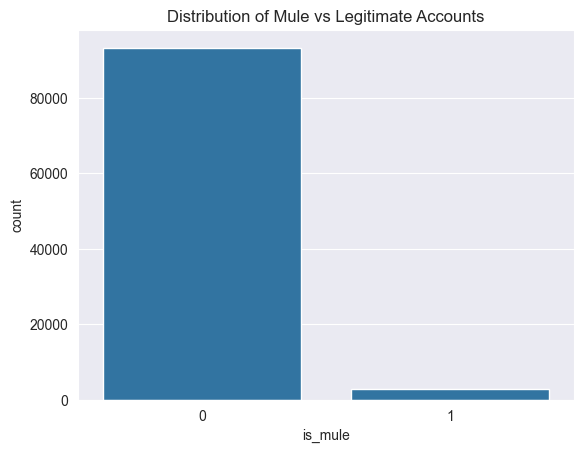

In [70]:
df["is_mule"].value_counts(normalize=True)
sns.countplot(x="is_mule", data=df)
plt.title("Distribution of Mule vs Legitimate Accounts")
plt.show()

## 6. Mule Account Distribution

Fraud detection datasets are typically **highly imbalanced**.  
We analyze the distribution of mule vs legitimate accounts.

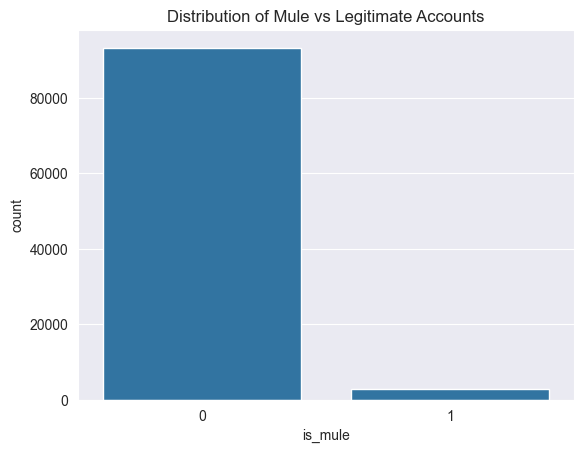

In [71]:
df["is_mule"].value_counts(normalize=True)
sns.countplot(x="is_mule", data=df)
plt.title("Distribution of Mule vs Legitimate Accounts")
plt.show()

### Observation

Mule accounts represent only a small fraction of accounts, confirming a **class imbalance problem**.  
Machine learning models must handle this imbalance carefully.

## 7. Account Age Analysis

Fraudsters often open new accounts specifically for laundering money.

We compute **account age in days** and compare mule vs legitimate accounts.

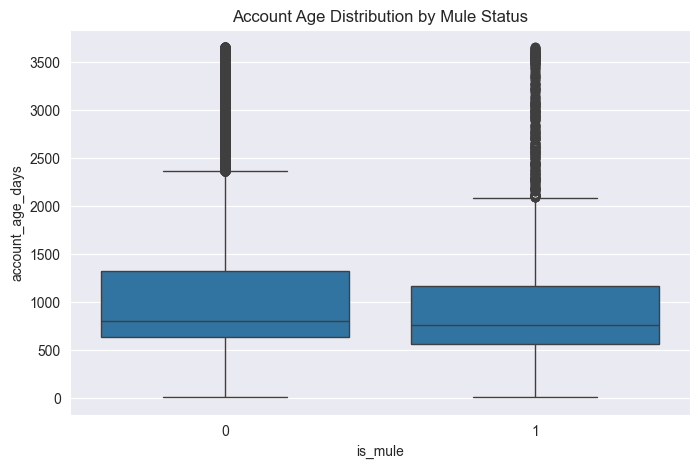

In [72]:
df["account_opening_date"] = pd.to_datetime(df["account_opening_date"])

df["account_age_days"] = (
    pd.Timestamp("2025-06-30") - df["account_opening_date"]
).dt.days

plt.figure(figsize=(8,5))
sns.boxplot(x="is_mule", y="account_age_days", data=df)
plt.title("Account Age Distribution by Mule Status")
plt.show()

## 8. Balance Behaviour Analysis

Mule accounts typically do not retain funds for long periods.  
Instead, money flows rapidly through them.

We analyze average account balances.

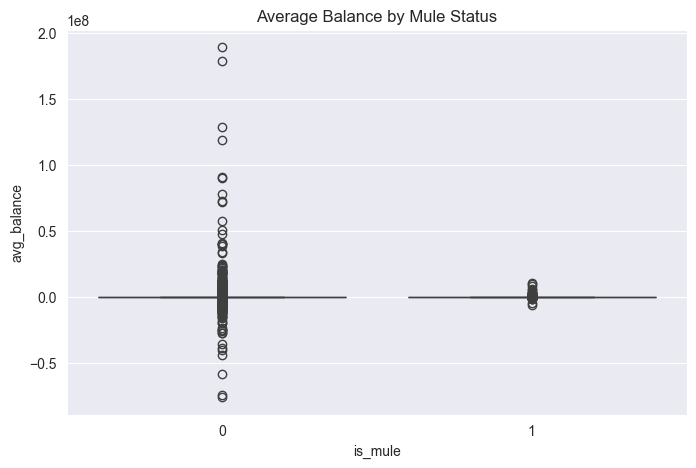

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_mule", y="avg_balance", data=df)
plt.title("Average Balance by Mule Status")
plt.show()

### Insight

Lower balances combined with high transaction activity may indicate **rapid pass-through behavior**.

## 9. Branch-Level Risk Profiling

Financial fraud often clusters geographically or operationally.  
Branches with weaker controls or located in high-risk regions may show higher concentrations of mule accounts.

In this section we analyze the **distribution of mule accounts across branch characteristics**.

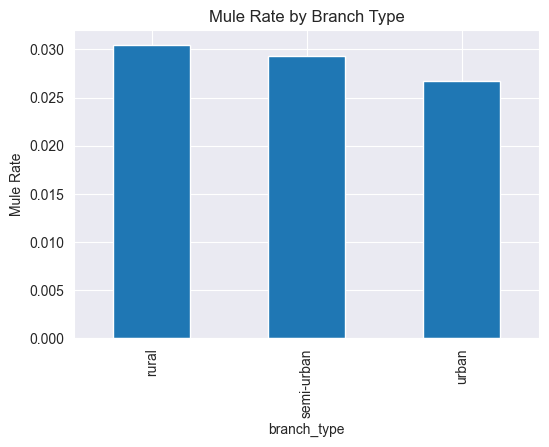

In [74]:
# Merge branch metadata
df = df.merge(branch, on="branch_code", how="left")
branch_summary = df.groupby("branch_type").agg(
    total_accounts=("account_id","count"),
    mule_accounts=("is_mule","sum")
)

branch_summary["mule_rate"] = branch_summary["mule_accounts"] / branch_summary["total_accounts"]

branch_summary
branch_summary["mule_rate"].plot(kind="bar", figsize=(6,4))
plt.title("Mule Rate by Branch Type")
plt.ylabel("Mule Rate")
plt.show()

### Insight

Branches with elevated mule rates may indicate:

- operational vulnerabilities
- fraud clusters
- poor KYC enforcement

## 10. Branch Economic Indicators

Branch size and transaction turnover may correlate with fraud exposure.
We analyze whether smaller or lower-capacity branches experience higher mule activity.

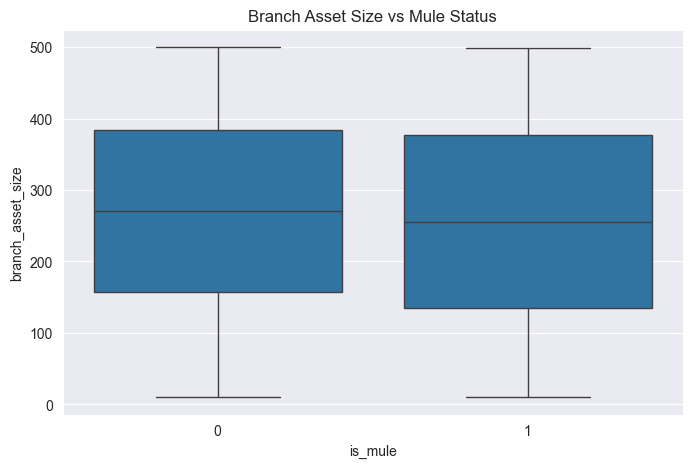

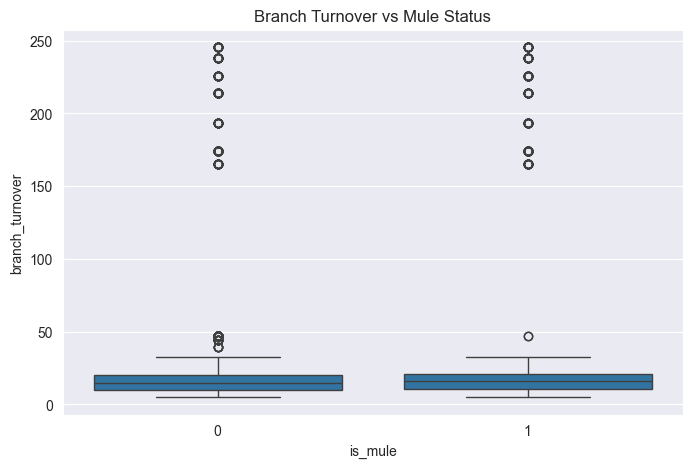

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_mule", y="branch_asset_size", data=df)
plt.title("Branch Asset Size vs Mule Status")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x="is_mule", y="branch_turnover", data=df)
plt.title("Branch Turnover vs Mule Status")
plt.show()

## 11. Transaction Data Sampling

The full transaction dataset contains hundreds of millions of records.
To perform interactive analysis we sample transactions using DuckDB.

In [76]:
con = duckdb.connect()

txn = con.execute("""
SELECT *
FROM '../data/transactions/batch-*/*.parquet'
LIMIT 3000000
""").df()

txn.head()
txn.shape

(3000000, 8)

## 12. Debit vs Credit Behavior

Understanding the balance between debit and credit transactions can reveal
rapid fund movement typical of mule accounts.

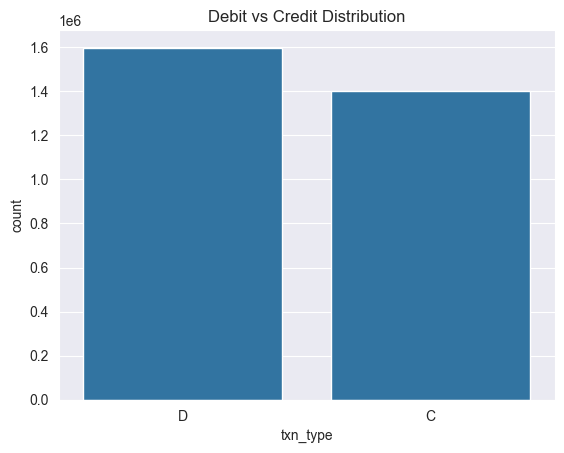

In [77]:
txn["txn_type"].value_counts()
sns.countplot(x="txn_type", data=txn)
plt.title("Debit vs Credit Distribution")
plt.show()

## 13. Transaction Channel Behavior

Money mule accounts frequently rely on digital payment channels such as:

- UPI
- IMPS
- P2A
- NEFT

These channels allow fast and anonymous fund movement.

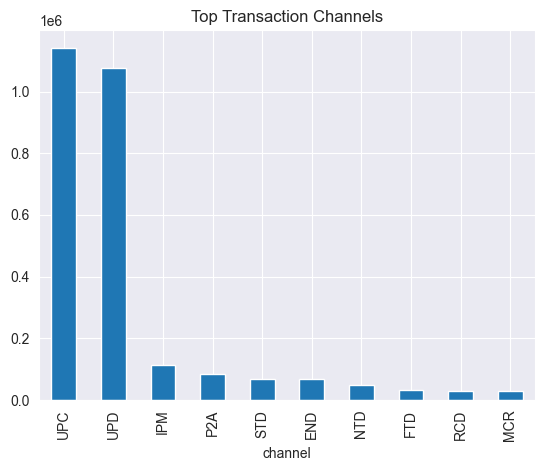

In [78]:
txn["channel"].value_counts().head(10)
txn["channel"].value_counts().head(10).plot(kind="bar")
plt.title("Top Transaction Channels")
plt.show()

## 14. Transaction Amount Patterns

Transaction value distributions can reveal structuring patterns or abnormal transfers.

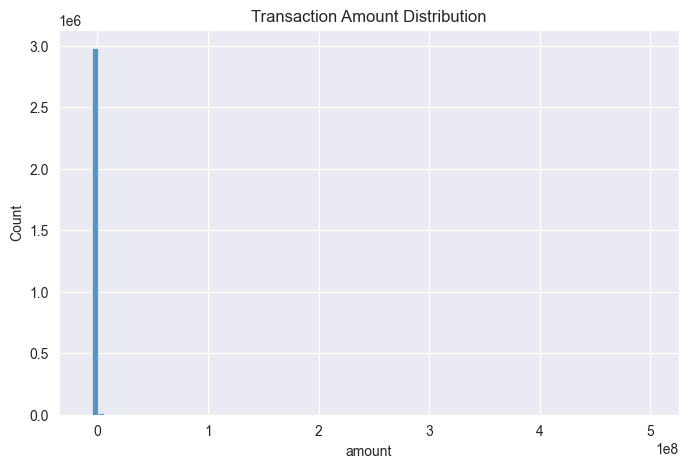

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(txn["amount"], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

## 15. Round Amount Analysis

Fraudsters often move funds in round numbers such as:

- 10,000
- 50,000
- 100,000

These patterns may indicate scripted or automated laundering activity.

In [80]:
txn["round_txn"] = txn["amount"] % 1000 == 0
txn["round_txn"].mean()

round_ratio = txn.groupby("account_id")["round_txn"].mean()

round_ratio.describe()

count    1214.000000
mean        0.179770
std         0.033081
min         0.000000
25%         0.173575
50%         0.179652
75%         0.185264
max         1.000000
Name: round_txn, dtype: float64

## 16. Counterparty Network Analysis

Mule accounts often interact with **many unique counterparties**.

Two common patterns:

- Fan-In: many senders → one account
- Fan-Out: one account → many receivers

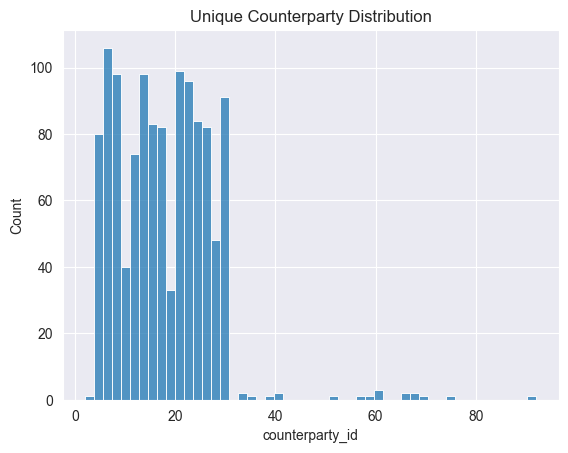

In [81]:
counterparty_counts = txn.groupby("account_id")["counterparty_id"].nunique()

counterparty_counts.describe()
sns.histplot(counterparty_counts, bins=50)
plt.title("Unique Counterparty Distribution")
plt.show()

## 17. Transaction Frequency Analysis

High transaction velocity is another strong indicator of mule activity.

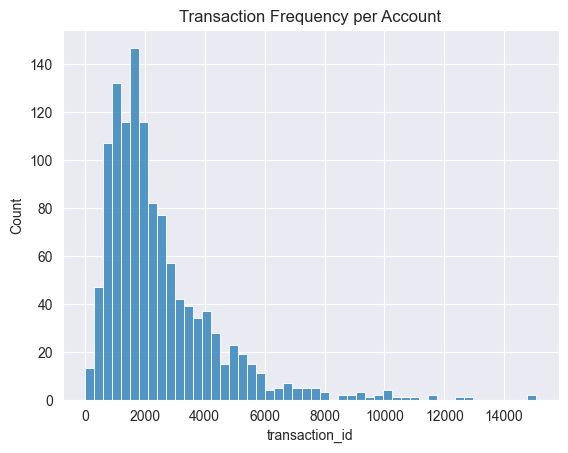

In [82]:
txn_frequency = txn.groupby("account_id")["transaction_id"].count()

txn_frequency.describe()
sns.histplot(txn_frequency, bins=50)
plt.title("Transaction Frequency per Account")
plt.show()

## 18. Prototype Transaction Features

To test potential signals we aggregate transactions at the account level.

In [83]:
txn_features = txn.groupby("account_id").agg(

    txn_count=("amount","count"),
    avg_txn_amount=("amount","mean"),
    max_txn_amount=("amount","max"),
    total_txn_volume=("amount","sum"),
    unique_counterparties=("counterparty_id","nunique")

).reset_index()

txn_features.head()

,account_id,txn_count,avg_txn_amount,max_txn_amount,total_txn_volume,unique_counterparties
0,ACCT_000000,2429,21813.272108,7964500.0,5.298444e+07,10
1,ACCT_000002,4038,28061.538252,7548000.0,1.133125e+08,29
2,ACCT_000003,2450,22581.386559,6801288.9,5.532440e+07,5
3,ACCT_000004,6256,29076.873462,23379300.0,1.819049e+08,28
4,ACCT_000005,554,15369.352256,1443000.0,8.514621e+06,20


## 19. Merge Aggregated Transaction Features

In [84]:
df = df.merge(txn_features, on="account_id", how="left")

df.head()

,account_id,account_status,product_code,currency_code,account_opening_date,branch_code,branch_pin,avg_balance,product_family,nomination_flag,cheque_allowed,cheque_availed,num_chequebooks,last_mobile_update_date,kyc_compliant,last_kyc_date,rural_branch,monthly_avg_balance,quarterly_avg_balance,daily_avg_balance,freeze_date,unfreeze_date,customer_id,date_of_birth,relationship_start_date,pan_available,aadhaar_available,passport_available,mobile_banking_flag,internet_banking_flag,atm_card_flag,demat_flag,credit_card_flag,fastag_flag,customer_pin,permanent_pin,is_mule,mule_flag_date,alert_reason,flagged_by_branch,account_age_days,branch_address,branch_pin_code,branch_city,branch_state,branch_employee_count,branch_turnover,branch_asset_size,branch_type,txn_count,avg_txn_amount,max_txn_amount,total_txn_volume,unique_counterparties
0,ACCT_000000,active,200,1,2023-08-30,7982,515008.0,53720.31,K,Y,Y,Y,0,NaN,Y,2023-11-04,Y,50111.60,55554.79,66771.57,NaN,NaN,CUST_000000,1950-07-15,2019-10-03,Y,Y,N,Y,Y,Y,N,Y,N,515008,515008,0,NaN,NaN,NaN,670,"95 Market Street, Guwahati",530055,Guwahati,Bihar,41,13.14,227.69,urban,2429.0,21813.272108,7964500.0,5.298444e+07,10.0
1,ACCT_000002,active,1133,1,2019-08-05,5479,144074.0,9492.82,O,N,N,N,0,NaN,Y,2021-10-03,N,9169.02,6925.45,8737.84,NaN,NaN,CUST_000002,1985-08-01,1999-08-19,N,N,N,Y,N,Y,N,N,N,144074,144074,0,NaN,NaN,NaN,2156,"127 Industrial Area, Panaji",226076,Panaji,Telangana,3,12.47,489.68,semi-urban,4038.0,28061.538252,7548000.0,1.133125e+08,29.0
2,ACCT_000003,active,146,1,2023-10-31,8227,190033.0,93286.70,S,N,Y,Y,3,NaN,Y,2024-10-25,N,86326.00,100171.75,78181.17,NaN,NaN,CUST_000003,1972-03-18,2018-04-28,N,Y,N,N,N,Y,N,N,N,190033,190033,0,NaN,NaN,NaN,608,"123 Main Road, Dehradun",520010,Dehradun,Maharashtra,31,12.24,343.44,semi-urban,2450.0,22581.386559,6801288.9,5.532440e+07,5.0
3,ACCT_000004,active,191,1,2017-11-25,3285,400035.0,555715.54,K,Y,Y,N,0,NaN,Y,2023-10-29,N,647193.23,509836.62,699191.21,NaN,NaN,CUST_000004,1971-11-06,2006-04-05,N,NaN,Y,N,N,N,N,Y,N,400035,400035,0,NaN,NaN,NaN,2774,"69 Industrial Area, Srinagar",282004,Srinagar,Odisha,21,5.64,478.34,urban,6256.0,29076.873462,23379300.0,1.819049e+08,28.0
4,ACCT_000008,frozen,897,1,2023-12-11,5486,249002.0,-28404.67,S,Y,Y,N,0,NaN,Y,2022-01-13,N,-26399.15,-20418.49,-24290.59,2022-03-15,NaN,CUST_000008,1957-06-29,2016-11-25,N,N,Y,Y,Y,Y,N,N,N,560029,342022,0,NaN,NaN,NaN,567,"65 Commercial Complex, Lucknow",760005,Lucknow,Maharashtra,5,13.53,472.01,urban,NaN,NaN,NaN,NaN,NaN


## 20. Fraud Signal Exploration

We examine whether transaction features differ significantly between mule and legitimate accounts.

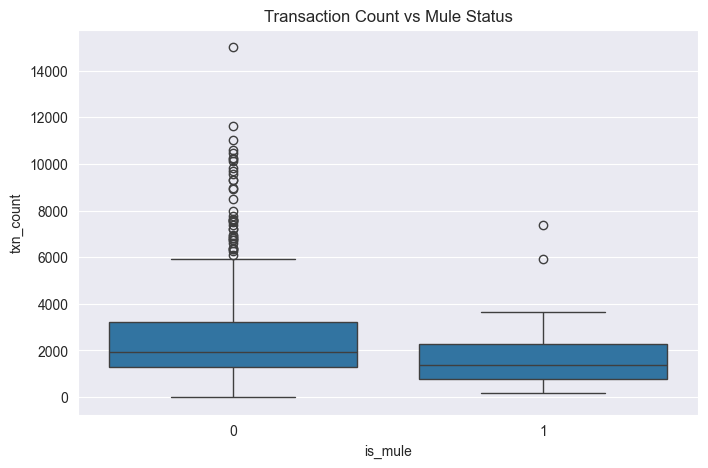

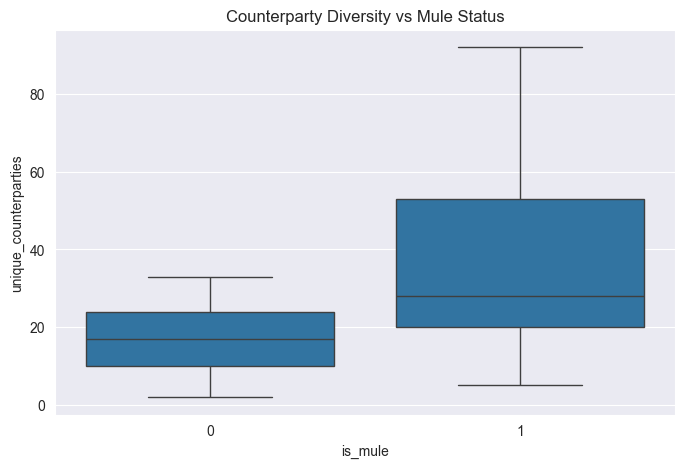

In [85]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_mule", y="txn_count", data=df)
plt.title("Transaction Count vs Mule Status")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x="is_mule", y="unique_counterparties", data=df)
plt.title("Counterparty Diversity vs Mule Status")
plt.show()


## 21. Baseline Mule Detection Model

We train a simple LightGBM classifier to validate whether the
constructed features carry predictive power.

In [86]:
features = [
    "account_age_days",
    "avg_balance",
    "txn_count",
    "avg_txn_amount",
    "max_txn_amount",
    "unique_counterparties"
]

X = df[features].fillna(0)
y = df["is_mule"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05
)

model.fit(X_train, y_train)

pred = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred)

[LightGBM] [Info] Number of positive: 2172, number of negative: 74700
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000961 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1120
[LightGBM] [Info] Number of data points in the train set: 76872, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028255 -> initscore=-3.537832
[LightGBM] [Info] Start training from score -3.537832


0.5656622824690255

## 22. Feature Importance Analysis

Understanding which features drive predictions helps interpret fraud signals.

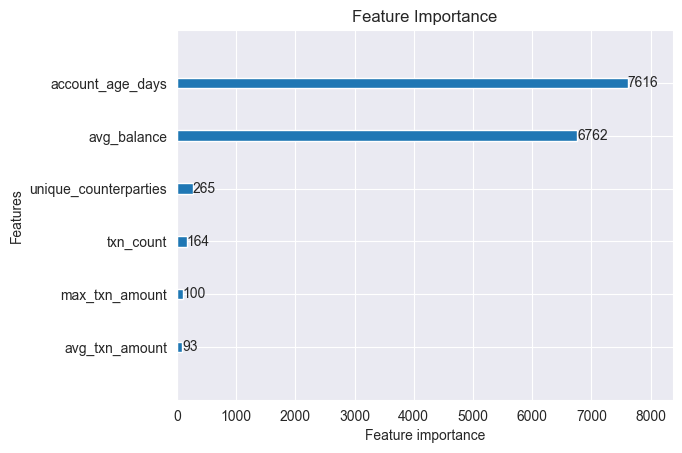

In [87]:
lgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

# Key Fraud Indicators Discovered

Through exploratory analysis we identified several behavioral signals:

1. Newly opened accounts show elevated mule risk.
2. Mule accounts often maintain lower balances.
3. Transaction frequency is significantly higher in mule accounts.
4. Counterparty diversity suggests fan-in/fan-out laundering networks.
5. Digital channels dominate suspicious activity.
6. Round-number transactions may indicate automated laundering scripts.

These findings guide the feature engineering process in the next stage.

## 24. Rapid Pass-Through Detection

One of the strongest signals of a mule account is **rapid pass-through behavior**.

Pattern:

1. Account receives a large credit
2. Funds are quickly transferred out
3. Balance remains near zero

This indicates the account is being used only as a temporary transfer node.

We measure the **time gap between credit and subsequent debit transactions**.

In [88]:
txn["transaction_timestamp"] = pd.to_datetime(txn["transaction_timestamp"])

txn = txn.sort_values(["account_id","transaction_timestamp"])
txn["next_time"] = txn.groupby("account_id")["transaction_timestamp"].shift(-1)
txn["next_type"] = txn.groupby("account_id")["txn_type"].shift(-1)
txn["time_gap"] = (
    txn["next_time"] - txn["transaction_timestamp"]
).dt.total_seconds()

pass_through = txn[
    (txn["txn_type"]=="C") &
    (txn["next_type"]=="D")
]
pass_through_feature = pass_through.groupby("account_id")["time_gap"].mean()

pass_through_feature.describe()
df["avg_pass_through_time"] = df["account_id"].map(pass_through_feature)

## 25. Dormant Account Activation

Another common mule pattern:

1. Account remains inactive for long periods
2. Suddenly begins large transaction bursts

This indicates compromised or rented accounts.

We calculate **days since last transaction**.

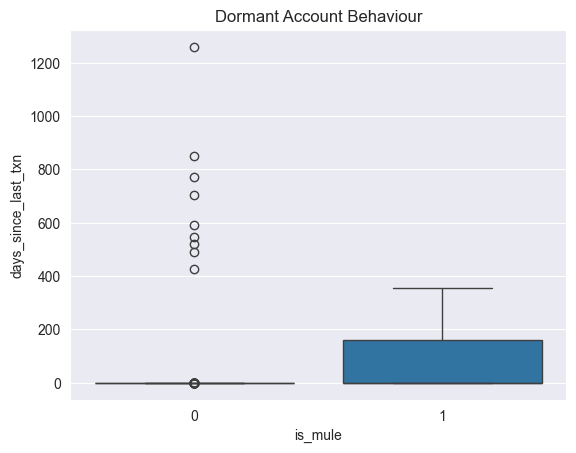

In [89]:
last_txn = txn.groupby("account_id")["transaction_timestamp"].max()

df["last_txn_time"] = df["account_id"].map(last_txn)

df["days_since_last_txn"] = (
    pd.Timestamp("2025-06-30") - df["last_txn_time"]
).dt.days
sns.boxplot(x="is_mule", y="days_since_last_txn", data=df)
plt.title("Dormant Account Behaviour")
plt.show()

## 26. Structuring Detection

Money laundering often involves splitting large transfers into smaller transactions
below regulatory thresholds.

Example:

Instead of ₹100,000 transfer → two ₹49,000 transfers.

We detect transactions close to ₹50,000.

In [90]:
txn["near_50k"] = (
    (txn["amount"] > 48000) &
    (txn["amount"] < 50000)
)
structuring_feature = txn.groupby("account_id")["near_50k"].sum()

df["near_50k_count"] = df["account_id"].map(structuring_feature)

## 27. Transaction Velocity

Transaction velocity measures **how frequently funds move through an account**.

High velocity may indicate laundering activity.

In [91]:
txn["date"] = txn["transaction_timestamp"].dt.date
daily_txn = txn.groupby(["account_id","date"]).size()
velocity_feature = daily_txn.groupby("account_id").mean()

df["txn_velocity"] = df["account_id"].map(velocity_feature)

## 28. Fan-In / Fan-Out Analysis

Mule accounts often operate as hubs in money laundering networks.

Patterns:

Fan-In:
Many accounts → one mule

Fan-Out:
One mule → many accounts

In [92]:
fan_in = txn.groupby("account_id")["counterparty_id"].nunique()
fan_out = txn.groupby("counterparty_id")["account_id"].nunique()
df["fan_in"] = df["account_id"].map(fan_in)
df["fan_out"] = df["account_id"].map(fan_out)

## 29. Transaction Time-of-Day Patterns

Fraud operations often occur during **late night hours** when monitoring is weaker.

In [93]:
txn["hour"] = txn["transaction_timestamp"].dt.hour
txn["night_txn"] = (
    (txn["hour"] >= 0) &
    (txn["hour"] <= 5)
)
night_ratio = txn.groupby("account_id")["night_txn"].mean()

df["night_txn_ratio"] = df["account_id"].map(night_ratio)

## 30. Geographic Anomaly Detection

Transactions occurring far from the customer's registered location
may indicate account compromise or mule networks.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

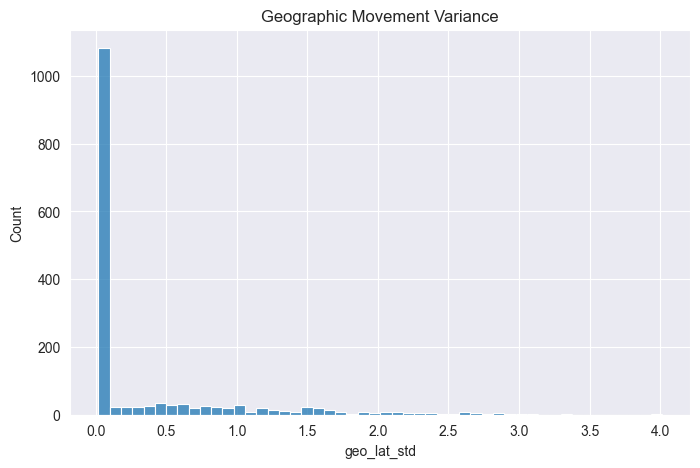

In [94]:
txn_geo = con.execute("""
SELECT 
    t.account_id,
    ta.latitude,
    ta.longitude
FROM '../data/transactions/batch-*/*.parquet' t
JOIN '../data/transactions_additional/batch-*/*.parquet' ta
ON t.transaction_id = ta.transaction_id
WHERE ta.latitude IS NOT NULL
LIMIT 1000000
""").df()
txn_geo.head()
geo_variance = txn_geo.groupby("account_id")[["latitude","longitude"]].std()

geo_variance.head()
df["geo_lat_std"] = df["account_id"].map(geo_variance["latitude"])
df["geo_lon_std"] = df["account_id"].map(geo_variance["longitude"])
plt.figure(figsize=(8,5))
sns.histplot(df["geo_lat_std"], bins=50)
plt.title("Geographic Movement Variance")
plt.show()

    ### Geographic Behavior Insight

Accounts showing large geographic variance may indicate:

• mule accounts used by multiple individuals  
• coordinated fraud networks  
• remote or automated transaction activity  

Legitimate accounts typically show transactions within a limited geographic region.

## 31. Combined Feature Set

We now combine behavioral, transactional, and account features.

In [95]:
features = [

"account_age_days",
"avg_balance",
"txn_count",
"avg_txn_amount",
"max_txn_amount",
"unique_counterparties",
"avg_pass_through_time",
"days_since_last_txn",
"near_50k_count",
"txn_velocity",
"fan_in",
"fan_out",
"night_txn_ratio"

]

## 32. Advanced Mule Detection Model

In [96]:
X = df[features].fillna(0)
y = df["is_mule"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    class_weight="balanced"
)
model.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, pred)

[LightGBM] [Info] Number of positive: 2172, number of negative: 74700
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1759
[LightGBM] [Info] Number of data points in the train set: 76872, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


0.5543585276158843

# Key Behavioral Signals Identified

Our analysis reveals several strong indicators of mule activity:

1. Rapid pass-through transactions
2. High counterparty diversity
3. High transaction velocity
4. Structuring near regulatory thresholds
5. Night-time transaction patterns
6. Fan-in / fan-out network behaviour
7. Dormant account reactivation

These signals will be expanded in the feature engineering stage.